<a href="https://colab.research.google.com/github/CaptainMarlow/IAD_labs/blob/main/IAD_Lab3_Sliepyi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Лабораторна робота №3 Виконана студентом групи ФБ-52мп Слєпим Романом.

In [13]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
import os
import urllib.request
import zipfile
import time
import cv2

In [11]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/nba_logreg.csv')

In [3]:
df = df.drop('name', axis=1)

In [4]:
results={}

АНАЛІЗ ДАТАСЕТУ
Структура датасету:
   gp   min  pts  fgm  fga    fg  3p_made  3pa    3p  ftm  fta    ft  oreb  \
0  36  27.4  7.4  2.6  7.6  34.7      0.5  2.1  25.0  1.6  2.3  69.9   0.7   
1  35  26.9  7.2  2.0  6.7  29.6      0.7  2.8  23.5  2.6  3.4  76.5   0.5   
2  74  15.3  5.2  2.0  4.7  42.2      0.4  1.7  24.4  0.9  1.3  67.0   0.5   
3  58  11.6  5.7  2.3  5.5  42.6      0.1  0.5  22.6  0.9  1.3  68.9   1.0   
4  48  11.5  4.5  1.6  3.0  52.4      0.0  0.1   0.0  1.3  1.9  67.4   1.0   

   dreb  reb  ast  stl  blk  tov  target_5yrs  
0   3.4  4.1  1.9  0.4  0.4  1.3          0.0  
1   2.0  2.4  3.7  1.1  0.5  1.6          0.0  
2   1.7  2.2  1.0  0.5  0.3  1.0          0.0  
3   0.9  1.9  0.8  0.6  0.1  1.0          1.0  
4   1.5  2.5  0.3  0.3  0.4  0.8          1.0  

Розмір датасету: (1340, 20)

Розподіл класів:
target_5yrs
1.0    831
0.0    509
Name: count, dtype: int64
Відсоток класу 1: 62.01%
Відсоток класу 0: 37.99%

 Виявлено пропущені значення. Заповнюємо середнім

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 187ms/step - accuracy: 0.6215 - auc: 0.6473 - loss: 0.8031 - val_accuracy: 0.6000 - val_auc: 0.7303 - val_loss: 0.7073 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6266 - auc: 0.6856 - loss: 0.7305 - val_accuracy: 0.6605 - val_auc: 0.7327 - val_loss: 0.6922 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6386 - auc: 0.6754 - loss: 0.7419 - val_accuracy: 0.6884 - val_auc: 0.7266 - val_loss: 0.6880 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6091 - auc: 0.6597 - loss: 0.7586 - val_accuracy: 0.6837 - val_auc: 0.7304 - val_loss: 0.6849 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6020 - auc: 0.6795 - loss: 0.7240 - val_accuracy: 0.6698 - val_auc: 0.7313 - val_loss: 0.6827 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6685 - auc: 0.712

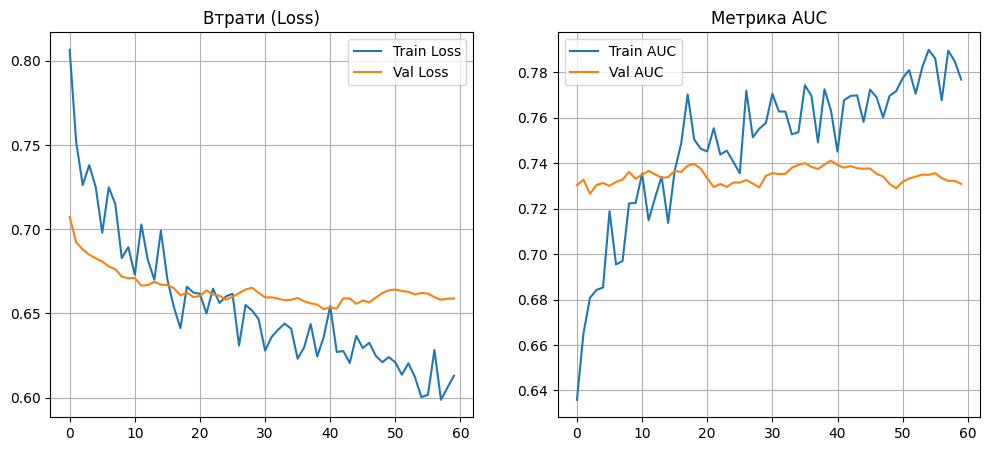

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step

Звіт класифікації:
              precision    recall  f1-score   support

      Клас 0       0.57      0.70      0.63       102
      Клас 1       0.78      0.68      0.73       166

    accuracy                           0.69       268
   macro avg       0.68      0.69      0.68       268
weighted avg       0.70      0.69      0.69       268


Матриця плутанини:
[[ 71  31]
 [ 53 113]]


In [5]:
# ---------------------------------------------------------
# 1. АНАЛІЗ ДАНИХ ТА ПІДГОТОВКА
# ---------------------------------------------------------

print("="*60)
print("АНАЛІЗ ДАТАСЕТУ")
print("="*60)

print("Структура датасету:")
print(df.head())
print(f"\nРозмір датасету: {df.shape}")

# Розподіл класів
counts = df['target_5yrs'].value_counts()
print(f"\nРозподіл класів:")
print(counts)
print(f"Відсоток класу 1: {df['target_5yrs'].mean()*100:.2f}%")
print(f"Відсоток класу 0: {(1-df['target_5yrs'].mean())*100:.2f}%")

# Обробка пропущених значень
if df.isnull().sum().sum() > 0:
    print("\n Виявлено пропущені значення. Заповнюємо середнім.")
    df = df.fillna(df.mean())
else:
    print("\n Пропущених значень немає.")

# Поділ на X та y
X = df.drop('target_5yrs', axis=1)
y = df['target_5yrs']

# Поділ на Train/Test (стратифікований, щоб зберегти пропорції класів)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Стандартизація
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nРозмір тренувальної вибірки: {X_train_scaled.shape}")
print(f"Розмір тестової вибірки: {X_test_scaled.shape}")

 # 2. ОБЧИСЛЕННЯ ВАГ КЛАСІВ
print("\n" + "="*60)
print("БАЛАНСУВАННЯ КЛАСІВ")
print("="*60)

# Обчислення ваг
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

# Конвертація у словник для Keras {0: вага, 1: вага}
class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print(f"Обчислені ваги класів: {class_weights}")

# Ініціалізація зміщення (bias) для вихідного шару
# Це допомагає моделі швидше зійтися на початку навчання при дисбалансі
initial_bias = np.log([y_train.mean() / (1 - y_train.mean())])
output_bias = tf.keras.initializers.Constant(initial_bias)

# ---------------------------------------------------------
# 3. АРХІТЕКТУРА НЕЙРОННОЇ МЕРЕЖІ (FFNN)
# ---------------------------------------------------------
print("\n" + "="*60)
print("ПОБУДОВА ТА НАВЧАННЯ МОДЕЛІ")
print("="*60)

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),

    # 1-й повнозв'язаний шар
    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    # 2-й повнозв'язаний шар
    layers.Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # 3-й повнозв'язаний шар
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),

    # Вихідний шар
    layers.Dense(1, activation='sigmoid', bias_initializer=output_bias)
])

# Компіляція
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

model.summary()

# ---------------------------------------------------------
# 4. НАЛАШТУВАННЯ CALLBACKS (EARLY STOPPING)
# ---------------------------------------------------------
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6,
        verbose=1
    )
]

# 5. НАВЧАННЯ

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# 6. ОЦІНКА ТА ВІЗУАЛІЗАЦІЯ

print("\n" + "="*60)
print("РЕЗУЛЬТАТИ")
print("="*60)

# Графіки
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax[0].plot(history.history['loss'], label='Train Loss')
ax[0].plot(history.history['val_loss'], label='Val Loss')
ax[0].set_title('Втрати (Loss)')
ax[0].legend()
ax[0].grid(True)

# AUC
ax[1].plot(history.history['auc'], label='Train AUC')
ax[1].plot(history.history['val_auc'], label='Val AUC')
ax[1].set_title('Метрика AUC')
ax[1].legend()
ax[1].grid(True)
plt.show()

# Фінальна оцінка
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

print("\nЗвіт класифікації:")
print(classification_report(y_test, y_pred, target_names=['Клас 0', 'Клас 1']))

print("\nМатриця плутанини:")
print(confusion_matrix(y_test, y_pred))

Приклад даних:
         Name        all_types
0   bulbasaur  [Grass, Poison]
1     ivysaur  [Grass, Poison]
2    venusaur  [Grass, Poison]
3  charmander           [Fire]
4  charmeleon           [Fire]

Унікальні класи (18): ['Bug' 'Dark' 'Dragon' 'Electric' 'Fairy' 'Fighting' 'Fire' 'Flying'
 'Ghost' 'Grass' 'Ground' 'Ice' 'Normal' 'Poison' 'Psychic' 'Rock' 'Steel'
 'Water']
Found 647 validated image filenames.
Found 162 validated image filenames.
Завантаження зображень у пам'ять...

Починаємо навчання...
Epoch 1/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 9s 247ms/step - binary_accuracy: 0.7920 - loss: 0.4802 - val_binary_accuracy: 0.9170 - val_loss: 0.2898
Epoch 2/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - binary_accuracy: 0.9042 - loss: 0.3336 - val_binary_accuracy: 0.9170 - val_loss: 0.2871
Epoch 3/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - binary_accuracy: 0.9123 - loss: 0.3074 - val_binary_accuracy: 0.9170 - val_loss: 0.2828
Epoch 4/150
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - binar

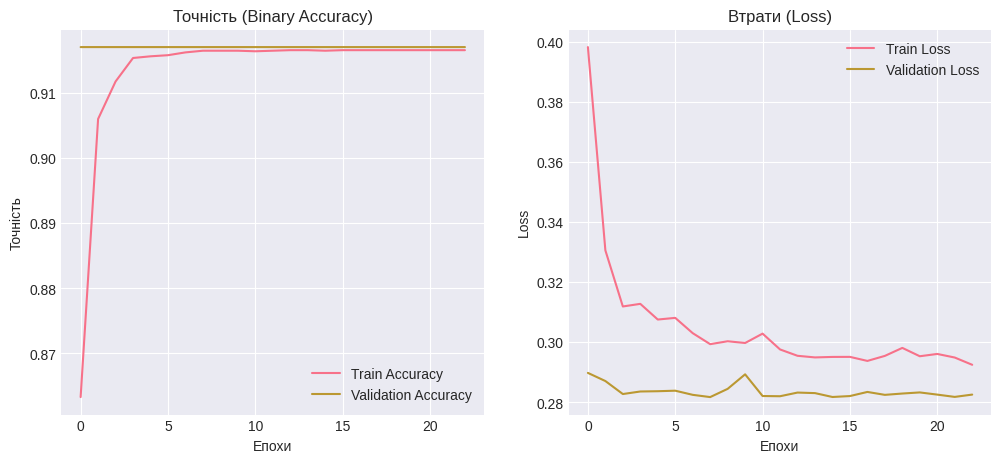

In [18]:
# ==========================================
# 1. НАЛАШТУВАННЯ ТА ПІДГОТОВКА ДАНИХ
# ==========================================
base_path = '/content/drive/MyDrive/Colab Notebooks/'
csv_path = os.path.join(base_path, 'pokemon.csv')  # Шлях до CSV
images_folder = os.path.join(base_path, 'images')  # Шлях до папки з фото

df = pd.read_csv(csv_path)

# 1.1. Формування шляхів до файлів
def get_filename(name):
    return f"{name}.png"  # Перевірте розширення (.png або .jpg)

df['filename'] = df['Name'].apply(get_filename)
df['file_path'] = df['filename'].apply(lambda x: os.path.join(images_folder, x))
df = df[df['file_path'].apply(os.path.exists)] # Залишаємо тільки існуючі фото
# 1.2. ПІДГОТОВКА МУЛЬТИЛЕЙБЛІВ
# Заповнюємо пропуски в Type2
df['Type2'] = df['Type2'].fillna('None')

# Створюємо колонку зі списком типів для кожного покемона
def combine_types(row):
    types = [row['Type1']]
    if row['Type2'] != 'None':
        types.append(row['Type2'])
    return types

df['all_types'] = df.apply(combine_types, axis=1)

print(f"Приклад даних:\n{df[['Name', 'all_types']].head()}")
mlb = MultiLabelBinarizer()
y = mlb.fit_transform(df['all_types'])
classes = mlb.classes_
print(f"\nУнікальні класи ({len(classes)}): {classes}")

train_idx, val_idx = train_test_split(df.index, test_size=0.2, random_state=42, stratify=df['Type1'])

train_df = df.loc[train_idx]
val_df = df.loc[val_idx]

y_train = y[train_idx] # Вектори міток для тренування
y_val = y[val_idx]     # Вектори міток для валідації

# ==========================================
# 2. ГЕНЕРАТОРИ (CUSTOM для Multi-label)
# ==========================================
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(rescale=1./255)

# Створюємо генератори
batch_size = 32

# Важливо: columns для y повинні відповідати порядку в df, тому ми використали індекси вище
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=images_folder,
    x_col="filename",
    y_col=None, # Ми не беремо y з датафрейму
    target_size=(120, 120),
    batch_size=batch_size,
    class_mode=None, # Ми повертаємо тільки X, а Y додамо вручну
    shuffle=False    # Важливо False, щоб порядок збігався з y_train
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=images_folder,
    x_col="filename",
    y_col=None,
    target_size=(120, 120),
    batch_size=batch_size,
    class_mode=None,
    shuffle=False
)

# Функція-обгортка, щоб поєднати картинки (X) і наші вектори міток (Y)
def multi_label_generator(generator, y_labels):
    while True:
        # Отримуємо індекси поточного батчу
        idx = generator.index_array
        # Генеруємо картинки
        batch_x = generator.next()
        pass

import cv2

def load_images(df, folder, size=(120, 120)):
    images = []
    for fname in df['filename']:
        img_path = os.path.join(folder, fname)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, size)
        images.append(img)
    return np.array(images)

print("Завантаження зображень у пам'ять...")
X_train_data = load_images(train_df, images_folder)
X_val_data = load_images(val_df, images_folder)

# Нормалізація
X_train_data = X_train_data.astype('float32') / 255.0
X_val_data = X_val_data.astype('float32') / 255.0

# Тепер генератор буде простим
train_gen_flow = datagen.flow(X_train_data, y_train, batch_size=32)
val_gen_flow = val_datagen.flow(X_val_data, y_val, batch_size=32)


# ==========================================
# 3. МОДЕЛЬ (VGG16 + SIGMOID)
# ==========================================
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(120, 120, 3))
base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(len(classes), activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['binary_accuracy']
)

# ==========================================
# 4. НАВЧАННЯ (З Early Stopping)
# ==========================================
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

print("\nПочинаємо навчання...")
history = model.fit(
    train_gen_flow,
    epochs=150,
    validation_data=val_gen_flow,
    callbacks=[early_stopping]
)

# ==========================================
# 5. ГРАФІКИ (Виносимо окремо!)
# ==========================================
acc_key = 'binary_accuracy'
val_acc_key = 'val_binary_accuracy'

plt.figure(figsize=(12, 5))

# Графік точності
plt.subplot(1, 2, 1)
plt.plot(history.history[acc_key], label='Train Accuracy')
plt.plot(history.history[val_acc_key], label='Validation Accuracy')
plt.title('Точність (Binary Accuracy)')
plt.xlabel('Епохи')
plt.ylabel('Точність')
plt.legend()
plt.grid(True)

# Графік втрат (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Втрати (Loss)')
plt.xlabel('Епохи')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

КЛАСИФІКАЦІЯ GOOGLE PLAY REVIEWS (ВИПРАВЛЕНО)
Використання існуючої колонки sentiment

[1] Завантаження та підготовка даних...
Розмір датасету: (62633, 11)
Колонки: ['reviewId', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'predicted_category', 'sentiment', 'appVersion']

[Обробка цільової змінної sentiment...]
Унікальні значення в колонці: ['NEUTRAL' 'NEGATIVE' 'POSITIVE']

Розподіл класів (0=Negative, 1=Neutral, 2=Positive):
label_id
0     6838
1     8718
2    47077
Name: count, dtype: int64

[Попередня обробка текстів...]
Розмір після очищення: (62571, 4)

[2] Токенізація...
Train shape: (50056, 100), Test shape: (12515, 100)

[3] Підготовка GloVe embeddings...
Завантаження GloVe з http://nlp.stanford.edu/data/glove.6B.zip...
✓ Завантажено 400000 векторів.
✓ Знайдено embeddings для 8897/10000 слів.

МОДЕЛЬ А: Random Embeddings
Epoch 1/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.8006 - loss: 0.5449 - val_accuracy: 0.8

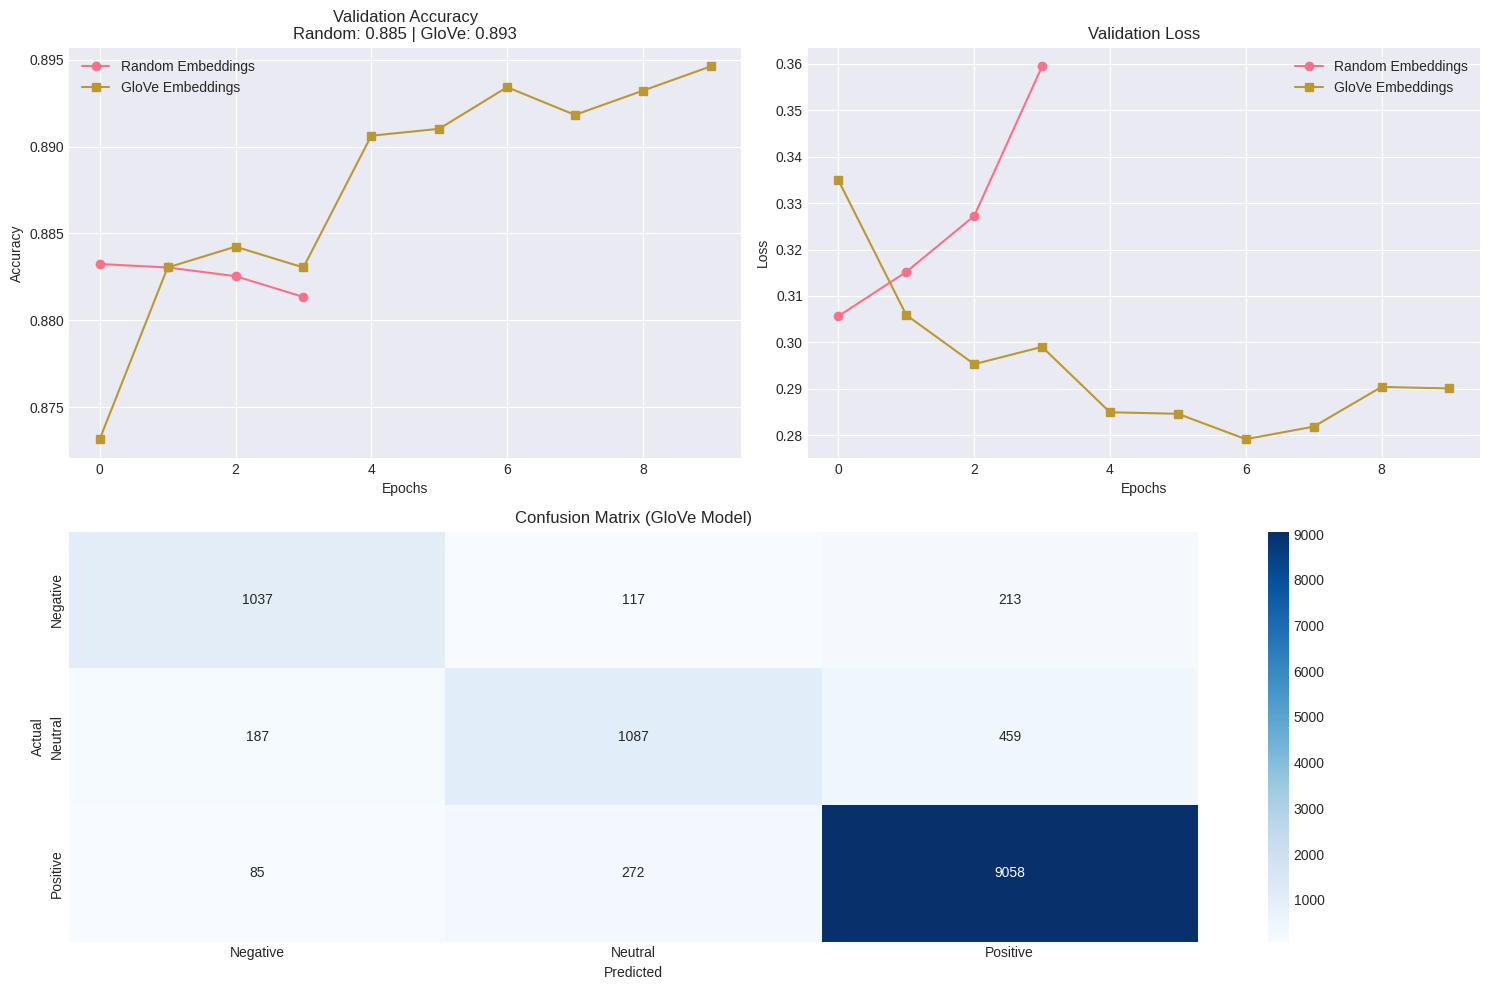


Час навчання Random: 65.97 сек
Час навчання GloVe: 140.68 сек

Classification Report (GloVe):
              precision    recall  f1-score   support

    Negative       0.79      0.76      0.78      1367
     Neutral       0.74      0.63      0.68      1733
    Positive       0.93      0.96      0.95      9415

    accuracy                           0.89     12515
   macro avg       0.82      0.78      0.80     12515
weighted avg       0.89      0.89      0.89     12515



In [6]:
# Налаштування
np.random.seed(42)
tf.random.set_seed(42)
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("КЛАСИФІКАЦІЯ GOOGLE PLAY REVIEWS (ВИПРАВЛЕНО)")
print("Використання існуючої колонки sentiment")
print("="*80)

# Завантаження NLTK ресурсів
try:
    nltk.download('punkt', quiet=True)
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt_tab', quiet=True)
except:
    pass

# ========== 1. ЗАВАНТАЖЕННЯ ТА ОБРОБКА ДАНИХ ==========
print("\n[1] Завантаження та підготовка даних.")

# 1.1 Завантаження
# Переконайтеся, що шлях до файлу правильний!
file_path = "/content/drive/MyDrive/Colab Notebooks/dataset.csv"
dft = pd.read_csv(file_path)

print(f"Розмір датасету: {dft.shape}")
print(f"Колонки: {list(dft.columns)}")

# Видалення зайвих колонок (залишаємо content і sentiment)
# Перевіряємо, чи існують колонки перед видаленням
available_cols = [col for col in ['content', 'sentiment'] if col in dft.columns]
dft = dft[available_cols]

if 'content' not in dft.columns or 'sentiment' not in dft.columns:
    raise ValueError("У датасеті відсутні колонки 'content' або 'sentiment'")

# ---------------------------------------------------------
# ОБРОБКА ІСНУЮЧОЇ КОЛОНКИ SENTIMENT
# ---------------------------------------------------------
print("\n[Обробка цільової змінної sentiment...]")
print("Унікальні значення в колонці:", dft['sentiment'].unique())

# Словник для конвертації тексту в числа
# Враховуємо різні варіанти написання
label_mapping = {
    'NEGATIVE': 0,
    'NEUTRAL':  1,
    'POSITIVE': 2
}

# Створюємо нову колонку з числовими мітками
dft['label_id'] = dft['sentiment'].map(label_mapping)

# Перевірка на помилки (NaN)
if dft['label_id'].isnull().any():
    n_errors = dft['label_id'].isnull().sum()
    print(f"⚠️ УВАГА: {n_errors} рядків не вдалося розпізнати. Видаляємо їх.")
    print("Проблемні значення:", dft[dft['label_id'].isnull()]['sentiment'].unique())
    dft = dft.dropna(subset=['label_id'])

# Перетворюємо в цілі числа
dft['label_id'] = dft['label_id'].astype(int)

# Виводимо статистику
print("\nРозподіл класів (0=Negative, 1=Neutral, 2=Positive):")
print(dft['label_id'].value_counts().sort_index())

# 1.2 Попередня обробка тексту
def preprocess_text(text):
    if isinstance(text, str):
        text = text.lower()
        text = text.translate(str.maketrans('', '', string.punctuation))
        tokens = word_tokenize(text)
        stop_words = set(stopwords.words('english'))
        filtered_tokens = [word for word in tokens if word not in stop_words]
        return ' '.join(filtered_tokens)
    else:
        return ""

print("\n[Попередня обробка текстів...]")
dft['content_preprocessed'] = dft['content'].apply(preprocess_text)

# Видалення порожніх рядків після очищення
dft = dft[dft['content_preprocessed'].str.len() > 0].reset_index(drop=True)
print(f"Розмір після очищення: {dft.shape}")

# ========== 2. ТОКЕНІЗАЦІЯ ==========
print("\n[2] Токенізація...")

MAX_WORDS = 10000
MAX_LEN = 100
EMBEDDING_DIM = 100
BATCH_SIZE = 64
EPOCHS = 15

texts = dft['content_preprocessed'].values
labels = dft['label_id'].values  # Використовуємо наші закодовані labels

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = labels

# Розділення на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

# ========== 3. GLOVE EMBEDDINGS ==========
def download_and_load_glove(embedding_dim=100):
    print("\n[3] Підготовка GloVe embeddings.")
    glove_file = f'glove.6B.{embedding_dim}d.txt'

    if not os.path.exists(glove_file):
        glove_zip = 'glove.6B.zip'
        if not os.path.exists(glove_zip):
            url = 'http://nlp.stanford.edu/data/glove.6B.zip'
            print(f"Завантаження GloVe з {url}")
            urllib.request.urlretrieve(url, glove_zip)

        with zipfile.ZipFile(glove_zip, 'r') as zip_ref:
            zip_ref.extract(glove_file)

    embeddings_index = {}
    with open(glove_file, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs

    print(f"Завантажено {len(embeddings_index)} векторів.")
    return embeddings_index

def create_embedding_matrix(embeddings_index, word_index, embedding_dim, max_words):
    num_words = min(max_words, len(word_index) + 1)
    embedding_matrix = np.zeros((num_words, embedding_dim))
    found = 0
    for word, i in word_index.items():
        if i >= max_words: continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
            found += 1
        else:
            embedding_matrix[i] = np.random.randn(embedding_dim) * 0.1
    print(f"Знайдено embeddings для {found}/{num_words} слів.")
    return embedding_matrix

# Завантаження GloVe
try:
    embeddings_index = download_and_load_glove(EMBEDDING_DIM)
    embedding_matrix = create_embedding_matrix(embeddings_index, tokenizer.word_index, EMBEDDING_DIM, MAX_WORDS)
except Exception as e:
    print(f"Помилка завантаження GloVe: {e}")
    print("Створення випадкової матриці.")
    embedding_matrix = np.random.randn(min(MAX_WORDS, len(tokenizer.word_index)+1), EMBEDDING_DIM)

# ========== 4. МОДЕЛЬ А (RANDOM) ==========
print("\n" + "="*40)
print("МОДЕЛЬ А: Random Embeddings")
print("="*40)

model_a = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.2)),
    Bidirectional(LSTM(32, dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_a.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time_a = time.time()
history_a = model_a.fit(
    X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2, verbose=1,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)
time_a = time.time() - start_time_a

# ========== 5. МОДЕЛЬ Б (GLOVE) ==========
print("\n" + "="*40)
print("МОДЕЛЬ Б: GloVe Embeddings")
print("="*40)

model_b = Sequential([
    Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, input_length=MAX_LEN,
              weights=[embedding_matrix], trainable=False), # False = не навчаємо ваги GloVe
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.2)),
    Bidirectional(LSTM(32, dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

model_b.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

start_time_b = time.time()
history_b = model_b.fit(
    X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
    validation_split=0.2, verbose=1,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)
time_b = time.time() - start_time_b

# ========== 6. РЕЗУЛЬТАТИ ТА ВІЗУАЛІЗАЦІЯ ==========
# Передбачення
y_pred_a = np.argmax(model_a.predict(X_test, verbose=0), axis=1)
y_pred_b = np.argmax(model_b.predict(X_test, verbose=0), axis=1)

acc_a = accuracy_score(y_test, y_pred_a)
acc_b = accuracy_score(y_test, y_pred_b)

# Візуалізація
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2)

# Графік точності
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history_a.history['val_accuracy'], label='Random Embeddings', marker='o')
ax1.plot(history_b.history['val_accuracy'], label='GloVe Embeddings', marker='s')
ax1.set_title(f'Validation Accuracy\nRandom: {acc_a:.3f} | GloVe: {acc_b:.3f}')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Графік втрат
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history_a.history['val_loss'], label='Random Embeddings', marker='o')
ax2.plot(history_b.history['val_loss'], label='GloVe Embeddings', marker='s')
ax2.set_title('Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

# Confusion Matrix для GloVe (зазвичай краща модель)
ax3 = fig.add_subplot(gs[1, :])
cm = confusion_matrix(y_test, y_pred_b)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3,
            xticklabels=['Negative', 'Neutral', 'Positive'],
            yticklabels=['Negative', 'Neutral', 'Positive'])
ax3.set_title('Confusion Matrix (GloVe Model)')
ax3.set_ylabel('Actual')
ax3.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

print(f"\nЧас навчання Random: {time_a:.2f} сек")
print(f"Час навчання GloVe: {time_b:.2f} сек")
print("\nClassification Report (GloVe):")
print(classification_report(y_test, y_pred_b, target_names=['Negative', 'Neutral', 'Positive']))